# NASA Airfoil Self-Noise: Advanced ML Prediction

## Problem Summary

**Goal.** Predict how loud an airfoil section is. Given five measured wind-tunnel quantities, the model predicts the **scaled sound pressure level (SSPL, dB)** of the noise the airfoil generates. This is a supervised **regression** problem.

![Airfoil self-noise: five inputs and the predicted noise level](attachment:airfoil_problem_summary.png)

| | Variable | Symbol | Unit | Meaning |
|---|---|---|---|---|
| Input | Frequency | f | Hz | Pitch of the noise component being measured (200 to 20,000 Hz) |
| Input | Angle of attack | α | degrees | Angle between the incoming flow and the chord line |
| Input | Chord length | c | m | Width of the airfoil section |
| Input | Free-stream velocity | U∞ | m/s | Wind-tunnel flow speed |
| Input | Suction-side displacement thickness | δ | m | Boundary-layer parameter on the upper (suction) surface |
| **Target** | Scaled sound pressure level | SSPL | dB | Intensity of the self-noise generated by the airfoil |

**Data.** 1,503 measurements from the NASA Langley Research Center anechoic wind tunnel (NACA 0012 airfoils of different sizes), loaded from Kaggle: `fedesoriano/airfoil-selfnoise-dataset`.

**Approach in this notebook**

| Step | What happens |
|---|---|
| 1. EDA | Distributions, correlations, outliers (physical stall conditions, not errors) |
| 2. Feature engineering | log frequency, stall flag, α², α·δ, Strouhal, Reynolds and Mach numbers |
| 3. Preprocessing | IQR outlier clipping and RobustScaler, **fitted on the training split only** to avoid data leakage |
| 4. Model comparison | 8 models compared on validation R², 5-fold CV, overfitting gap and training time |
| 5. Tuning | Randomized search for Random Forest, Gradient Boosting, Ridge and the Voting Ensemble |
| 6. Final model | Best tuned model by validation R², evaluated once on the untouched test set, saved with a model card |

### ✈️ What is an airfoil?

An airfoil (or aerofoil) is a cross-sectional shape designed to generate aerodynamic lift when moving through a fluid such as air. It is the characteristic shape of aircraft wings, helicopter blades, wind turbine blades, sails and propellers.

When fluid flows around an airfoil, the air passing over the curved upper surface travels faster than the air under the flatter lower surface. By Bernoulli's principle this gives **lower pressure on the upper surface** and **higher pressure on the lower surface**. The pressure difference produces lift.

### ✈️ Why predicting noise matters

* **Acoustic quieting**: helps design quieter wind turbine blades, helicopter rotors and commercial aircraft, reducing community noise.
* **Aerodynamic optimization**: lets designers weigh lift (performance) against self-noise (emissions).
* **Virtual prototyping**: an accurate predictor reduces expensive, slow wind-tunnel tests in early design phases.

In [7]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
fedesoriano_airfoil_selfnoise_dataset_path = kagglehub.dataset_download('fedesoriano/airfoil-selfnoise-dataset')

print('Data source import complete.')

Using Colab cache for faster access to the 'airfoil-selfnoise-dataset' dataset.
Data source import complete.


In [8]:
import numpy as np
!pip install mlflow
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 🛠️ Advanced imports for production ML

# Suppress warnings for cleaner outputs
import warnings
warnings.filterwarnings('ignore')

# 🔧 Core Python libraries
import numpy as np           # Efficient numerical computations
import pandas as pd          # Data manipulation and analysis
import matplotlib.pyplot as plt  # Basic plotting
import seaborn as sns        # Advanced visualization
from scipy import stats      # Statistical functions
import joblib               # Save/load large models and preprocessing objects
import json                 # Handle JSON configs and outputs
from datetime import datetime  # Timestamping for logs
import os                   # File system operations
import time                 # Time tracking for experiments

# 🧰 Sklearn libraries - expanded for advanced ML workflows
from sklearn.model_selection import (
    train_test_split,     # Split data into train/test sets
    cross_val_score,      # Cross-validation scoring
    GridSearchCV,         # Hyperparameter tuning (grid search)
    RandomizedSearchCV    # Hyperparameter tuning (randomized search)
)
from sklearn.preprocessing import (
    StandardScaler,       # Feature scaling (zero-mean, unit variance)
    RobustScaler,         # Scaling robust to outliers
    PolynomialFeatures    # Generate polynomial features for non-linear relationships
)
from sklearn.pipeline import Pipeline, FeatureUnion  # Build modular pipelines
from sklearn.compose import ColumnTransformer         # Apply different preprocessing to columns
from sklearn.feature_selection import (
    SelectKBest,          # Univariate feature selection
    f_regression,         # Scoring function for regression
    RFE                   # Recursive feature elimination
)
from sklearn.linear_model import (
    LinearRegression,     # Baseline regression
    Ridge,                # L2-regularized regression
    Lasso,                # L1-regularized regression
    ElasticNet            # Combination of L1 and L2 regularization
)
from sklearn.ensemble import (
    RandomForestRegressor,       # Ensemble of decision trees
    GradientBoostingRegressor,   # Boosted trees for regression
    VotingRegressor              # Combine multiple regressors
)
from sklearn.svm import SVR               # Support Vector Regression
from sklearn.metrics import (
    mean_squared_error,  # Regression metric
    r2_score,            # Regression metric
    mean_absolute_error  # Regression metric
)
from sklearn.inspection import (
    permutation_importance,       # Feature importance
    PartialDependenceDisplay      # Partial dependence plots
)

# 🧪 Advanced model tracking with MLflow
import mlflow                  # Experiment tracking
import mlflow.sklearn          # Log sklearn models
from mlflow.models.signature import infer_signature  # Auto-capture input/output schema for reproducible deployment

## 📦 Summary of Imported Libraries

To build and track our machine learning models, we have imported a professional set of Python libraries grouped by their specific purpose:

### 1. Data Manipulation & Numerical Computing
* **`numpy` (np)**: Efficiently handles multi-dimensional arrays and high-performance mathematical computations.
* **`pandas` (pd)**: Provides structure through DataFrames, making data cleaning, loading (CSV files), and manipulation straightforward.

### 2. Data Visualization
* **`matplotlib.pyplot` (plt)**: The foundational plotting library used for creating static, interactive, and customized charts (such as line plots).
* **`seaborn` (sns)**: Built on top of Matplotlib, it produces highly attractive and informative statistical graphics like correlation heatmaps.

### 3. Machine Learning Frameworks (`scikit-learn`)
* **Data Splitting & Cross-Validation**: Tools like `train_test_split` and `cross_val_score` ensure robust evaluation models on unseen datasets.
* **Feature Scaling**: `StandardScaler` and `RobustScaler` adjust numerical ranges so different magnitudes (such as Frequency vs. Chord Length) do not bias our algorithms.
* **Regression Models**: Algorithms like `LinearRegression`, `Ridge`, `Lasso`, and ensemble systems like `RandomForestRegressor`, `GradientBoostingRegressor`, and `VotingRegressor` used to predict the Sound Pressure Level (SSPL).
* **Metrics**: Evaluation functions like `mean_squared_error` ($MSE$), `mean_absolute_error` ($MAE$), and $R^2$ scores to measure prediction quality.

### 4. Advanced MLOps & Experiment Tracking
* **`mlflow`**: A state-of-the-art framework used to log hyperparameters, save trained pipeline architectures, and keep track of experimental metric runs over time.

In [9]:
# 🎛️ Configuration & Reproducibility

#Before we start modeling, it’s crucial to **establish reproducible and scalable experiment settings**. This ensures that results are consistent, experiments are traceable, and your workflow is production-ready.

import os
import mlflow
# Allow the local file store tracking backend for MLflow
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

class Config:
    # Reproducibility - Critical for production!
    RANDOM_STATE = 42
    TEST_SIZE = 0.2
    VAL_SIZE = 0.2  # NEW: Validation set for tuning
    CV_FOLDS = 5
    N_JOBS = -1  # Use all available cores

    # Model directories - Organized project structure
    MODEL_DIR = "models"
    EXPERIMENT_DIR = "experiments"

    # Create directories if they don't exist
    os.makedirs(MODEL_DIR, exist_ok=True)
    os.makedirs(EXPERIMENT_DIR, exist_ok=True)

config = Config()

# Initialize MLflow for experiment tracking
mlflow.set_tracking_uri(f"file://{os.path.abspath(config.EXPERIMENT_DIR)}")
experiment_name = "airfoil_self_noise_advanced"
mlflow.set_experiment(experiment_name)

2026/10/08 04:15:56 INFO mlflow.tracking.fluent: Experiment with name 'airfoil_self_noise_advanced' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///content/experiments/496778802226232458', creation_time=1791432956818, effective_trace_archival_retention=None, experiment_id='496778802226232458', last_update_time=1791432956818, lifecycle_stage='active', name='airfoil_self_noise_advanced', tags={}, trace_location=None, workspace='default'>

In [10]:
import kagglehub
import pandas as pd

try:
    fedesoriano_airfoil_selfnoise_dataset_path
except NameError:
    fedesoriano_airfoil_selfnoise_dataset_path = kagglehub.dataset_download('fedesoriano/airfoil-selfnoise-dataset')

array([[<Axes: title={'center': 'f'}>, <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'c'}>,
        <Axes: title={'center': 'U_infinity'}>],
       [<Axes: title={'center': 'delta'}>,
        <Axes: title={'center': 'SSPL'}>]], dtype=object)

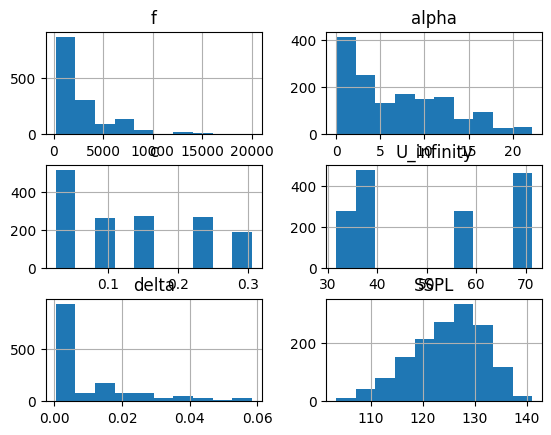

In [11]:
df = pd.read_csv(f"{fedesoriano_airfoil_selfnoise_dataset_path}/AirfoilSelfNoise.csv")
df.hist()

In [12]:
df = pd.read_csv(f"{fedesoriano_airfoil_selfnoise_dataset_path}/AirfoilSelfNoise.csv")
df

,f,alpha,c,U_infinity,delta,SSPL
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461
...,...,...,...,...,...,...
1498,2500,15.6,0.1016,39.6,0.052849,110.264
1499,3150,15.6,0.1016,39.6,0.052849,109.254
1500,4000,15.6,0.1016,39.6,0.052849,106.604
1501,5000,15.6,0.1016,39.6,0.052849,106.224


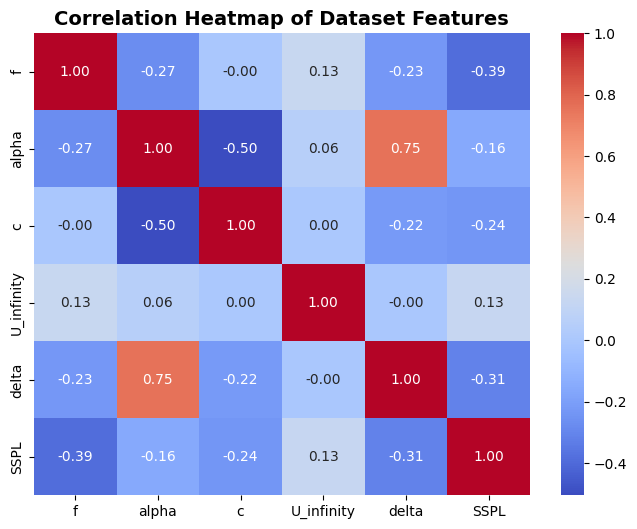

In [13]:
# Compute correlation matrix and plot heatmap using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Dataset Features', fontsize=14, fontweight='bold')
plt.show()

### Reading the correlation heatmap

**Correlation with the target (SSPL)**

| Feature | Correlation | Reading |
|---|---|---|
| Suction-side displacement thickness (δ) | -0.31 | Weak to moderate negative: thicker boundary layer, slightly lower SSPL |
| Frequency (f) | -0.29 | Weak negative: higher frequencies tend to have slightly lower SSPL |
| Chord length (c) | -0.24 | Weak negative: larger chords are weakly associated with lower self-noise |
| Angle of attack (α) | -0.16 | Very weak negative |
| Free-stream velocity (U∞) | 0.13 | Very weak positive |

**Strongest feature-to-feature correlations**

| Pair | Correlation | Reading |
|---|---|---|
| α and δ | 0.75 | Strong positive: the boundary layer thickens as angle of attack rises |
| c and δ | -0.22 | Weak negative |
| f and δ | -0.23 | Weak negative |


In [14]:
dgrees=df['delta']

In [15]:
# Calculate standard deviation for each column in the dataframe
df_std = df.std()
display(df_std)

,0
f,3152.573137
alpha,5.918128
c,0.093541
U_infinity,15.572784
delta,0.013150
SSPL,6.898657


0.011139880391217565


<Axes: >

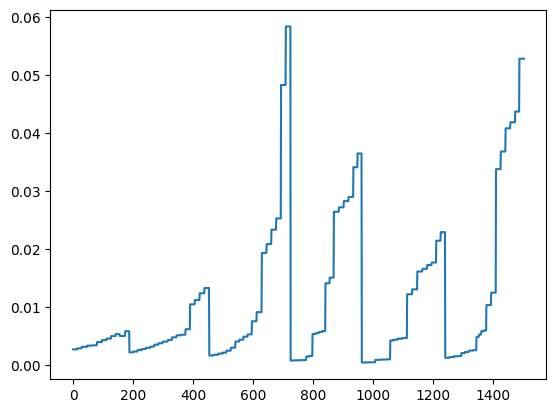

In [16]:
dgrees = df['delta']
print(dgrees.mean())
dgrees.plot.line()

2886.3805721889553
200
20000
3152.573136930677


<Axes: >

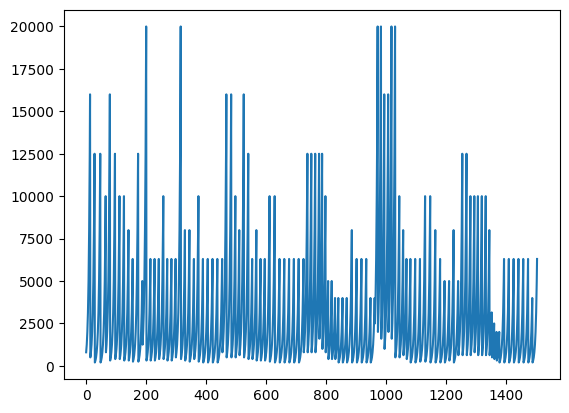

In [17]:
fregunsy=df['f']
print(fregunsy.mean())
print(fregunsy.min())
print(fregunsy.max())
print(fregunsy.std())
fregunsy.plot.line()

124.83594278110448
103.38
140.987
6.898656621628728


<Axes: >

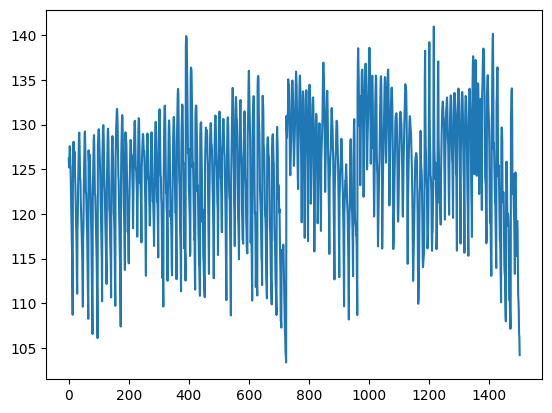

In [18]:
sspl=df["SSPL"]
print(sspl.mean())
print(sspl.min())
print(sspl.max())
print(sspl.std())
sspl.plot.line()

In [19]:
df.mean()

,0
f,2886.380572
alpha,6.782302
c,0.136548
U_infinity,50.860745
delta,0.011140
SSPL,124.835943


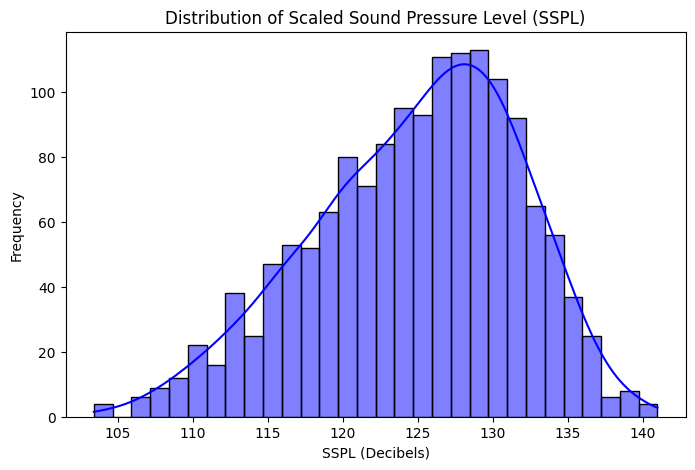

In [20]:
# 1. Distribution of Target Variable (SSPL)
plt.figure(figsize=(8, 5))
sns.histplot(df['SSPL'], kde=True, color='blue', bins=30)
plt.title('Distribution of Scaled Sound Pressure Level (SSPL)')
plt.xlabel('SSPL (Decibels)')
plt.ylabel('Frequency')
plt.show()

### *📊Exploratory Data Analysis (EDA)

Based on the statistical properties of the features and target variables, we can draw the following conclusions regarding the dataset's distribution, skewness, and extreme values:

#### 1. Statistical Dispersion & Spread
* **Extreme Scales**: The standard deviation of the **Frequency (`f`)** is extremely high (**3,152.57 Hz**), spanning a massive range from **200 Hz** to **20,000 Hz**. This reveals that frequency is exponentially spaced in typical acoustic studies, and the model must handle features that stretch across multiple orders of magnitude.
* **Angle of Attack (`alpha`)**: Has a mean of **6.78°** but exhibits a standard deviation of **5.92°**. It reaches up to **22.2°**, representing a transition from clean linear aerodynamic flow to highly turbulent stalled states.
* **Suction Side Displacement Thickness (`delta`)**: Represents the smallest physical scale in the dataset, with a mean of **0.011 meters** (11 mm) and a standard deviation of **0.013 meters**.

#### 2. Outlier Identification and Physical Meaning
* **High-Thickness Outliers (`delta`)**: While 75% of the measurements have a boundary layer thickness under **0.015 meters**, the maximum value reaches **0.058 meters** (nearly 5x the average). These extreme values are not data collection errors; they are physical "outliers" occurring during extreme **stall conditions** where high angles of attack drastically distort air flow over the suction side of the airfoil.
* **Noise Level Limits**: The Sound Pressure Level (`SSPL`) lower boundary around **103.38 dB** acts as a baseline tail. There are no dramatic noise level outliers on the high side (max **140.99 dB**), indicating that acoustic pressure saturates naturally within these wind tunnel velocities.

#### 3. Impact on Modeling
* Given the presence of heavily skewed features (like `f` and `delta`), standardizing variables with a scaler robust to outliers (such as `RobustScaler` or log-transforms) will be highly beneficial for linear algorithms, though tree-based ensembles like the Random Forest will be naturally resilient to these extreme distributions.

# 🧠 Advanced Feature Engineering

In [21]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class AerodynamicFeatureEngineer(BaseEstimator, TransformerMixin):

    def __init__(self, drop_original=False):
        # الثوابت الفيزيائية عند مستوى سطح البحر
        self.KINEMATIC_VISCOSITY = 1.46e-5  # متر مربع / ثانية
        self.SPEED_OF_SOUND = 343.0         # متر / ثانية
        self.drop_original = drop_original

    def fit(self, X, y=None):
        # لا توجد متغيرات داخلية تحتاج للتدريب في هذه المرحلة
        return self

    def transform(self, X):
        # أخذ نسخة لتجنب تعديل البيانات الأصلية بالخطأ
        df = X.copy()

        # 1. التحويل اللوغاريتمي للتردد (لمعالجة التوزيع شديد الانحراف والنطاق الواسع)
        if 'f' in df.columns:
            df['log_f'] = np.log1p(df['f'])

        # 2. مؤشر انهيار الرفع الديناميكي (Stall Indicator) والمربع التربيعي لزاوية الهجوم
        if 'alpha' in df.columns:
            df['is_stalled'] = (df['alpha'] >= 10.0).astype(int)
            df['alpha_squared'] = df['alpha'] ** 2

        # 3. مصطلح التفاعل بين الزاوية وسماكة الطبقة الحدودية (لمعالجة الارتباط الخطي المتعدد)
        if 'alpha' in df.columns and 'delta' in df.columns:
            df['alpha_delta_interaction'] = df['alpha'] * df['delta']

        # 4. رقم ستروهال (Strouhal Number) - المقياس الأهم في الصوتيات الهوائية
        if all(col in df.columns for col in ['f', 'delta', 'U_infinity']):
            df['strouhal_number'] = (df['f'] * df['delta']) / df['U_infinity']

        # 5. رقم رينولدز الفعال (Reynolds Number) - لتصنيف اضطراب الطبقة الحدودية
        if all(col in df.columns for col in ['U_infinity', 'c']):
            df['reynolds_number'] = (df['U_infinity'] * df['c']) / self.KINEMATIC_VISCOSITY

        # 6. رقم ماخ (Mach Number)
        if 'U_infinity' in df.columns:
            df['mach_number'] = df['U_infinity'] / self.SPEED_OF_SOUND

        # إزالة الأعمدة الأصلية إذا تم التحديد لتخفيف تداخل الميزات
        if self.drop_original:
            # يمكن الاستغناء عن التردد الأصلي بعد حساب التحويل اللوغاريتمي ورقم ستروهال
            columns_to_drop = ['f']
            df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

        return df

In [22]:
# ==========================================
#
if __name__ == "__main__":


    # فصل الميزات (X) عن الهدف (y)
    X = df.drop(columns=['SSPL'])
    y = df['SSPL']

    # 2. إنشاء كائن معالجة الميزات
    feature_engineer = AerodynamicFeatureEngineer(drop_original=True)

    # 3. تطبيق التحويلات وتجهيز البيانات
    X_transformed = feature_engineer.transform(X)

    # استعراض البيانات المعالجة
    print("الميزات الجاهزة للنمذجة:")
    print(X_transformed.columns.tolist())

الميزات الجاهزة للنمذجة:
['alpha', 'c', 'U_infinity', 'delta', 'log_f', 'is_stalled', 'alpha_squared', 'alpha_delta_interaction', 'strouhal_number', 'reynolds_number', 'mach_number']


In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.base import BaseEstimator, TransformerMixin

In [24]:
# 1. Define the missing OutlierHandler class
class OutlierHandler(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor
        self.lower_bounds_ = {}
        self.upper_bounds_ = {}

    def fit(self, X, y=None):
        # Calculate IQR boundaries for numeric columns
        for col in X.columns:
            if np.issubdtype(X[col].dtype, np.number):
                q25, q75 = np.percentile(X[col], [25, 75])
                iqr = q75 - q25
                self.lower_bounds_[col] = q25 - (self.factor * iqr)
                self.upper_bounds_[col] = q75 + (self.factor * iqr)
        return self

    def transform(self, X):
        X_copy = X.copy()
        # Clip outliers to bounds
        for col in X_copy.columns:
            if col in self.lower_bounds_:
                X_copy[col] = np.clip(X_copy[col], self.lower_bounds_[col], self.upper_bounds_[col])
        return X_copy

In [25]:
# 2. Create comprehensive preprocessing pipeline using AerodynamicFeatureEngineer
preprocessor = Pipeline([
    ('feature_engineer', AerodynamicFeatureEngineer(drop_original=True)),  # Our actual engineered features
    ('outlier_handler', OutlierHandler(factor=1.5)),                     # Handle outliers safely
    ('scaler', RobustScaler())                                           # Robust to remaining scale issues
])

In [26]:
# FIX (data leakage): split the RAW data first, then fit the preprocessor on the
# training part only. Before, fit_transform(X, y) ran on all 1503 rows, so the
# IQR outlier bounds and RobustScaler median/IQR were computed with validation
# and test rows included.
X_temp_raw, X_test_raw, y_temp, y_test = train_test_split(
    X, y, test_size=config.TEST_SIZE, random_state=config.RANDOM_STATE
)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp_raw, y_temp, test_size=config.VAL_SIZE, random_state=config.RANDOM_STATE
)

print("🔄 Fitting preprocessing pipeline on the TRAINING split only...")
preprocessor.fit(X_train_raw, y_train)          # statistics come from train rows only
X_train = preprocessor.transform(X_train_raw)   # val/test are only transformed, never fitted
X_val = preprocessor.transform(X_val_raw)
X_test = preprocessor.transform(X_test_raw)

print("✅ ADVANCED PREPROCESSING PIPELINE BUILT!")
print(f"📊 Processed shapes: train {X_train.shape}, val {X_val.shape}, test {X_test.shape}")

print(f"📊 DATA SPLITS (IMPROVED from previous notebook):")
print(f"• Training: {X_train.shape[0]:,} samples (model learning)")
print(f"• Validation: {X_val.shape[0]:,} samples (hyperparameter tuning)")
print(f"• Test: {X_test.shape[0]:,} samples (final evaluation - NEVER TOUCHED until end)")

🔄 Fitting preprocessing pipeline on the TRAINING split only...
✅ ADVANCED PREPROCESSING PIPELINE BUILT!
📊 Processed shapes: train (961, 11), val (241, 11), test (301, 11)
📊 DATA SPLITS (IMPROVED from previous notebook):
• Training: 961 samples (model learning)
• Validation: 241 samples (hyperparameter tuning)
• Test: 301 samples (final evaluation - NEVER TOUCHED until end)


In [27]:
# define advanced models - Expanded from previous work
advanced_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=config.RANDOM_STATE),
    'Lasso Regression': Lasso(random_state=config.RANDOM_STATE),
    'ElasticNet': ElasticNet(random_state=config.RANDOM_STATE),  # NEW: Combines L1 + L2
    'Random Forest': RandomForestRegressor(random_state=config.RANDOM_STATE, n_jobs=config.N_JOBS),
    'Gradient Boosting': GradientBoostingRegressor(random_state=config.RANDOM_STATE),  # NEW: Sequential learning
    'Support Vector Regression': SVR(),  # NEW: Different approach
}

In [28]:
# NEW: Voting Ensemble - Combines multiple models
voting_ensemble = VotingRegressor([
    ('ridge', Ridge(random_state=config.RANDOM_STATE)),
    ('rf', RandomForestRegressor(random_state=config.RANDOM_STATE, n_jobs=config.N_JOBS)),
    ('gb', GradientBoostingRegressor(random_state=config.RANDOM_STATE))
])

advanced_models['Voting Ensemble'] = voting_ensemble

print(f"\n🎯 MODEL PORTFOLIO ({len(advanced_models)} models):")


🎯 MODEL PORTFOLIO (8 models):


In [29]:
#📦 Helper 1 — Basic training and evaluation
# ===========================
def train_and_evaluate(model, X_train, y_train, X_val, y_val):
    """Train model and compute basic metrics on train and validation sets."""
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    metrics = {
        "train_rmse": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "val_rmse": np.sqrt(mean_squared_error(y_val, y_val_pred)),
        "train_r2": r2_score(y_train, y_train_pred),
        "val_r2": r2_score(y_val, y_val_pred),
        "train_mae": mean_absolute_error(y_train, y_train_pred),
        "val_mae": mean_absolute_error(y_val, y_val_pred),
        "training_time": training_time,
        "overfitting_gap": r2_score(y_train, y_train_pred) - r2_score(y_val, y_val_pred) # EARLY DETECTION FOR OVERFITTING
    }

    return metrics, model

In [30]:
# ===========================
# 📦 Helper 2 — Cross-validation
# ===========================
def compute_cross_validation(model, X_train, y_train, cv_folds=config.CV_FOLDS):
    """Run cross-validation and return mean and std of R² scores."""
    cv_scores = cross_val_score(model, X_train, y_train,
                                cv=cv_folds, scoring='r2', n_jobs=config.N_JOBS)
    return cv_scores.mean(), cv_scores.std()

In [31]:
# ===========================
# 📦 Helper 3 — MLflow Logging
# ===========================
def log_to_mlflow(model, metrics, cv_mean, cv_std, run_name):
    """Log params, metrics, and model to MLflow in a clean, minimal way."""
    with mlflow.start_run(run_name=run_name):
        # 1. Log hyperparameters
        mlflow.log_params(model.get_params())

        # 2. Log main metrics
        for k, v in metrics.items():
            if k != 'training_time':  # avoid logging long times directly
                mlflow.log_metric(k, float(v))
        mlflow.log_metric("cv_r2_mean", float(cv_mean))
        mlflow.log_metric("cv_r2_std", float(cv_std))

        # 3. Save model artifact
        mlflow.sklearn.log_model(
            sk_model=model,  # FIX: was grid_search.best_estimator_ (undefined name)
            artifact_path="model",
            serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE
        )

def evaluate_model_advanced(model, X_train, X_val, y_train, y_val, model_name):
    """Train, evaluate, cross-validate, and log model in a clean step-by-step way."""
    # 1. Train and evaluate
    metrics, trained_model = train_and_evaluate(model, X_train, y_train, X_val, y_val)

    # 2. Cross-validation
    cv_mean, cv_std = compute_cross_validation(model, X_train, y_train)
    metrics["cv_r2_mean"] = cv_mean
    metrics["cv_r2_std"] = cv_std

    # 3. Log everything to MLflow
    log_to_mlflow(model, metrics, cv_mean, cv_std, model_name)

    return metrics, trained_model

In [32]:
# Redefining the helper to patch the NameError caused by the typo 'trained_model'
def evaluate_model_advanced(model, X_train, X_val, y_train, y_val, model_name):
    """Train, evaluate, cross-validate, and log model in a clean step-by-step way."""
    # 1. Train and evaluate
    metrics, trained_model = train_and_evaluate(model, X_train, y_train, X_val, y_val)

    # 2. Cross-validation
    cv_mean, cv_std = compute_cross_validation(model, X_train, y_train)
    metrics["cv_r2_mean"] = cv_mean
    metrics["cv_r2_std"] = cv_std

    # 3. Log everything to MLflow
    log_to_mlflow(model, metrics, cv_mean, cv_std, model_name)

    return metrics, trained_model

print("🚀 STARTING ADVANCED MODEL EVALUATION...")
results = {}
trained_models = {}

for name, model in advanced_models.items():
    print(f"\n🔧 Training {name}...")
    metrics, trained_model = evaluate_model_advanced(model, X_train, X_val, y_train, y_val, name)

    results[name] = metrics
    trained_models[name] = trained_model

    overfit_flag = "⚠️" if metrics['overfitting_gap'] > 0.1 else "✅"
    print(f"✅ {name:20} | Val R²: {metrics['val_r2']:.4f} | "
          f"CV R²: {metrics['cv_r2_mean']:.4f} ± {metrics['cv_r2_std']:.4f} {overfit_flag}")

print("\n📈 All models trained and logged to MLflow!")
print(f"💡 Launch MLflow UI with: mlflow ui --backend-store-uri {config.EXPERIMENT_DIR}")

🚀 STARTING ADVANCED MODEL EVALUATION...

🔧 Training Linear Regression...


2026/10/08 04:16:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/08 04:16:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/08 04:16:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Linear Regression    | Val R²: 0.4411 | CV R²: 0.5268 ± 0.0707 ⚠️

🔧 Training Ridge Regression...


2026/10/08 04:16:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/08 04:16:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/08 04:16:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Ridge Regression     | Val R²: 0.4410 | CV R²: 0.5274 ± 0.0702 ⚠️

🔧 Training Lasso Regression...


...

✅ Gradient Boosting    | Val R²: 0.8669 | CV R²: 0.8782 ± 0.0136 ✅

🔧 Training Support Vector Regression...


2026/10/08 04:17:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/08 04:17:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Support Vector Regression | Val R²: 0.7039 | CV R²: 0.7309 ± 0.0295 ✅

🔧 Training Voting Ensemble...


2026/10/08 04:17:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/08 04:17:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Voting Ensemble      | Val R²: 0.8198 | CV R²: 0.8432 ± 0.0213 ✅

📈 All models trained and logged to MLflow!
💡 Launch MLflow UI with: mlflow ui --backend-store-uri experiments


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
# ===========================
# 1️⃣ Convert results dict to DataFrame
# ===========================
metrics_df = pd.DataFrame(results).T  # transpose so models are rows
metrics_df = metrics_df[['val_r2', 'val_rmse', 'val_mae', 'overfitting_gap', 'cv_r2_mean']]
metrics_df = metrics_df.reset_index().rename(columns={'index': 'Model'})

print("📊 Model comparison table:")
display(metrics_df)

📊 Model comparison table:


,Model,val_r2,val_rmse,val_mae,overfitting_gap,cv_r2_mean
0,Linear Regression,0.441091,5.363183,4.088555,0.108346,0.526804
1,Ridge Regression,0.441009,5.363577,4.088948,0.108415,0.527412
2,Lasso Regression,0.328852,5.877074,4.790371,0.081779,0.396724
3,ElasticNet,0.299809,6.002892,4.829448,0.077390,0.360133
4,Random Forest,0.917217,2.064061,1.520780,0.071405,0.908882
5,Gradient Boosting,0.866912,2.617111,1.932093,0.058926,0.878184
6,Support Vector Regression,0.703898,3.903670,2.896570,0.068100,0.730938
7,Voting Ensemble,0.819842,3.044940,2.279929,0.083011,0.843221


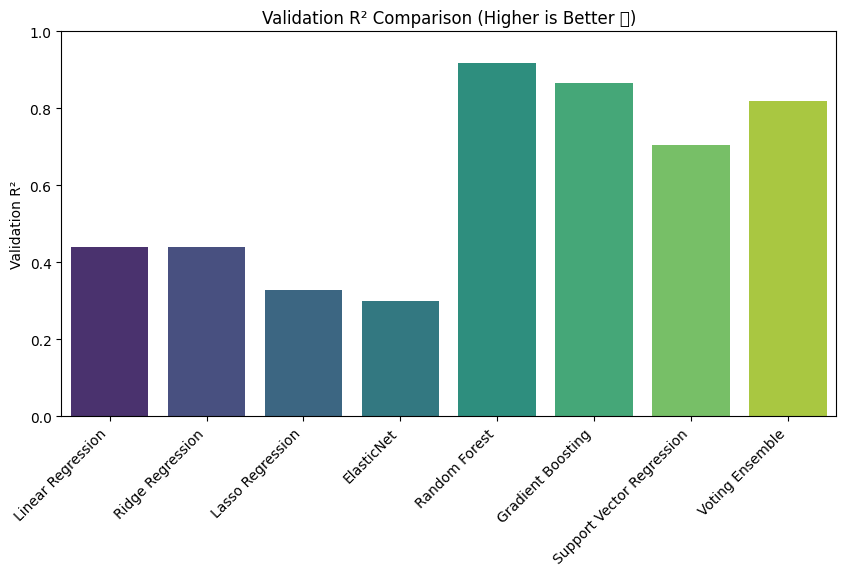

In [35]:
# ===========================
# 2️⃣ Plot Validation R² (Higher is better)
# ===========================
plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_df, x='Model', y='val_r2', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Validation R² Comparison (Higher is Better ✅)')
plt.ylabel('Validation R²')
plt.xlabel('')
plt.ylim(0, 1)
plt.show()

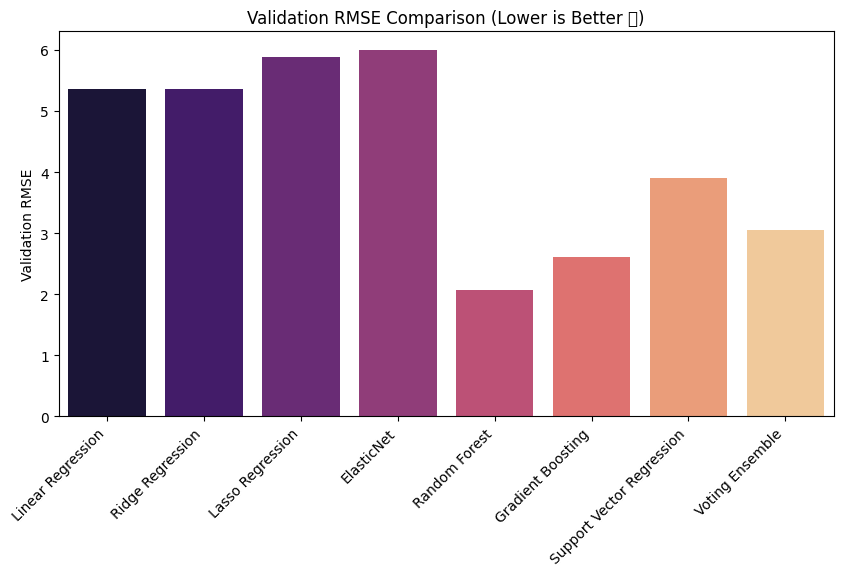

In [36]:
# ===========================
# 3️⃣ Plot Validation RMSE (Lower is better)
# ===========================
plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_df, x='Model', y='val_rmse', palette='magma')
plt.xticks(rotation=45, ha='right')
plt.title('Validation RMSE Comparison (Lower is Better ✅)')
plt.ylabel('Validation RMSE')
plt.xlabel('')
plt.show()

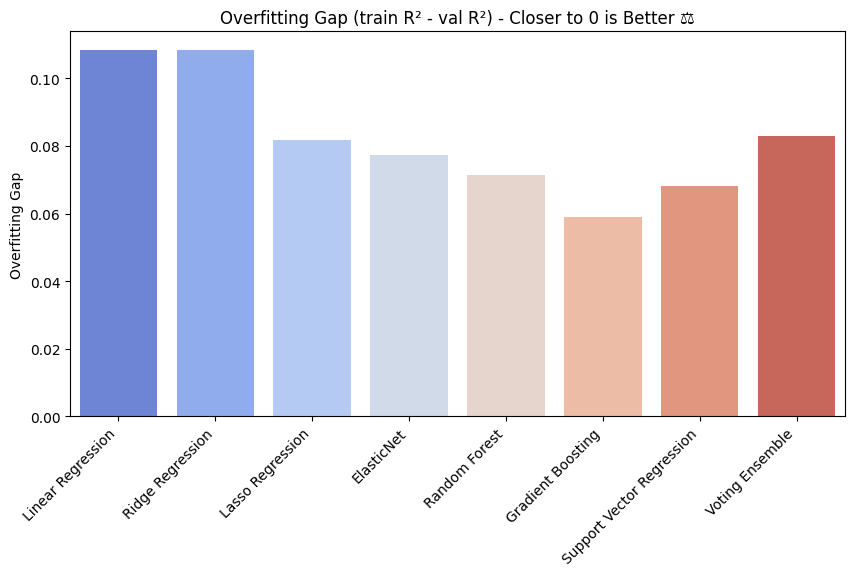

In [37]:
# ===========================
# 4️⃣ Plot Overfitting Gap (Closer to 0 is better)
# ===========================
plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_df, x='Model', y='overfitting_gap', palette='coolwarm')
plt.xticks(rotation=45, ha='right')
plt.title('Overfitting Gap (train R² - val R²) - Closer to 0 is Better ⚖️')
plt.ylabel('Overfitting Gap')
plt.xlabel('')
plt.show()

📈 ADVANCED MODEL COMPARISON

🏆 MODEL PERFORMANCE RANKING
Model                     Val R²   CV R²        Overfitting  Time (s)  
--------------------------------------------------------------------------------
Random Forest              0.9172  0.9089 ± 0.0114   ✅  0.0714      1.29
Gradient Boosting          0.8669  0.8782 ± 0.0136   ✅  0.0589      0.26
Voting Ensemble            0.8198  0.8432 ± 0.0213   ✅  0.0830      0.86
Support Vector Regression  0.7039  0.7309 ± 0.0295   ✅  0.0681      0.11
Linear Regression          0.4411  0.5268 ± 0.0707  ⚠️  0.1083      0.02
Ridge Regression           0.4410  0.5274 ± 0.0702  ⚠️  0.1084      0.01
Lasso Regression           0.3289  0.3967 ± 0.0550   ✅  0.0818      0.01
ElasticNet                 0.2998  0.3601 ± 0.0326   ✅  0.0774      0.00


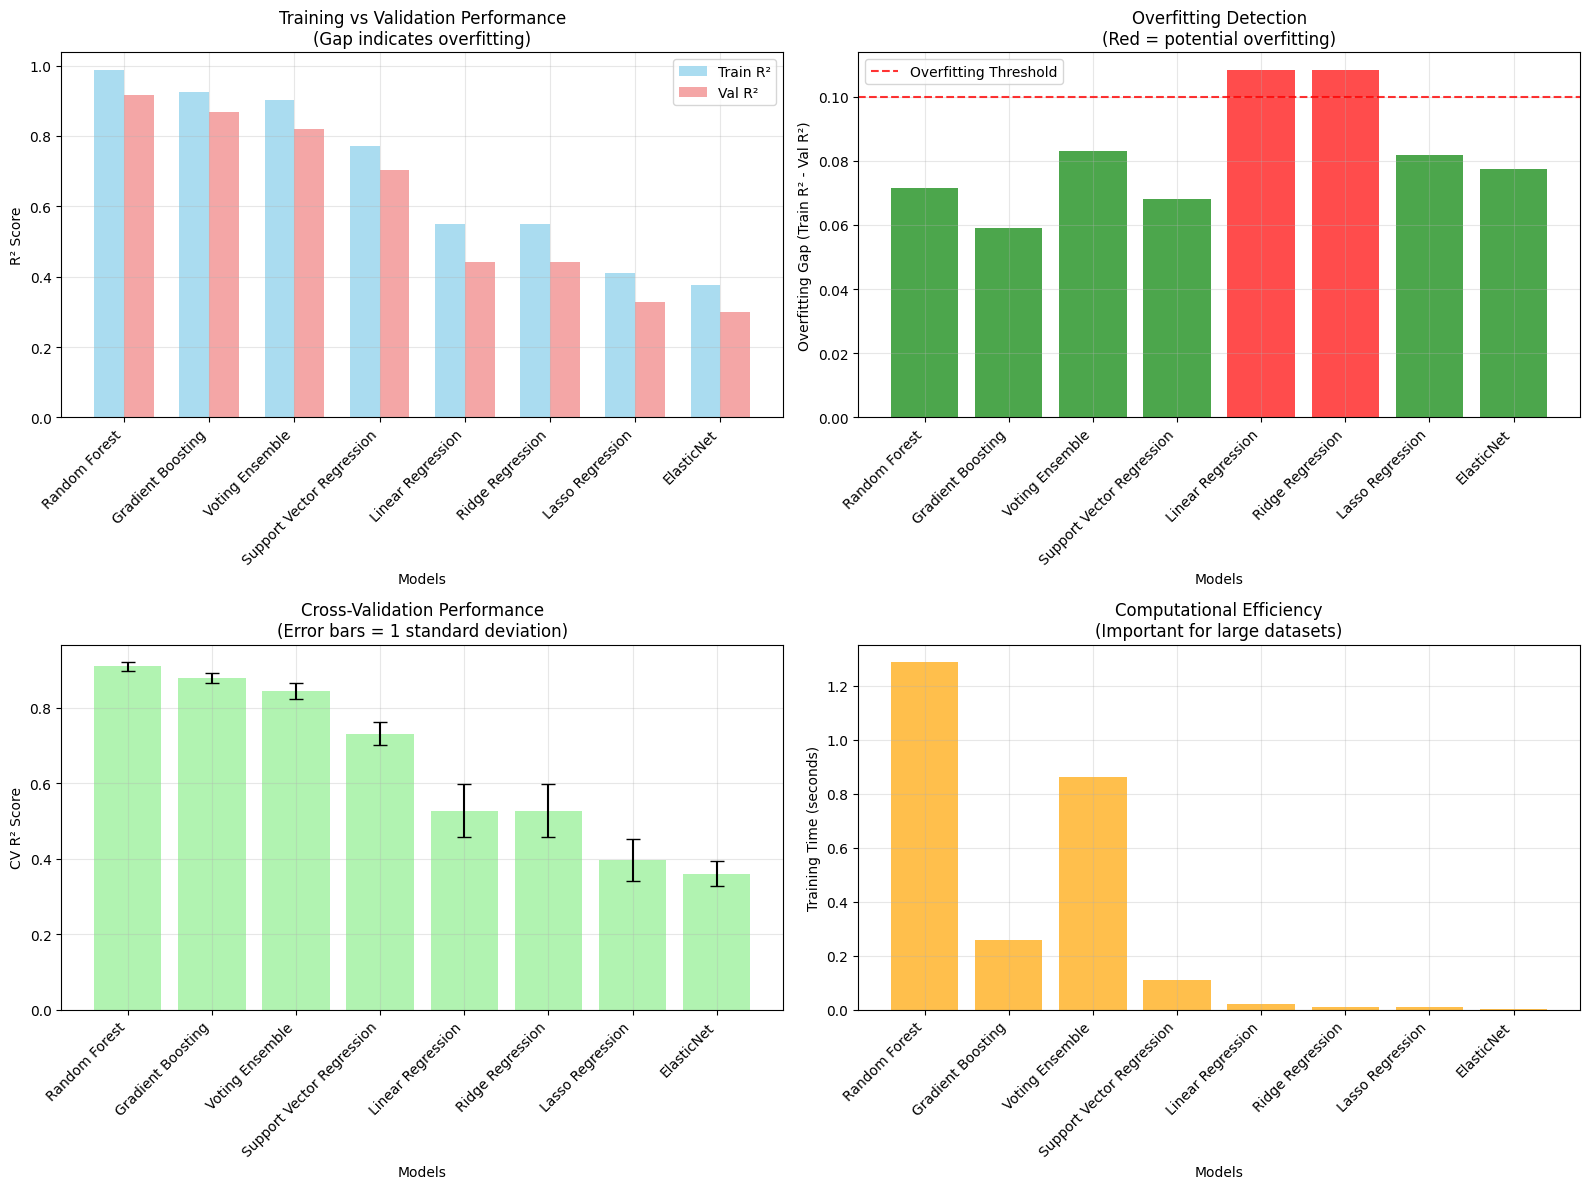


🎯 BEST MODEL SELECTED: Random Forest
📊 Validation R²: 0.9172
🔍 CV R²: 0.9089 ± 0.0114

💡 INTERPRETATION GUIDE:
• Good: High R², small train-val gap, stable CV, reasonable training time
• Overfitting: Large gap between train and validation performance
• Unstable: Large CV standard deviation
• Best choice: Balances performance, stability, and efficiency


In [38]:
# 📈 CELL 7: Advanced Model Comparison Visualization
print("📈 ADVANCED MODEL COMPARISON")

# Create comprehensive results dataframe
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('val_r2', ascending=False)

print("\n" + "=" * 80)
print("🏆 MODEL PERFORMANCE RANKING")
print("=" * 80)
print(f"{'Model':<25} {'Val R²':<8} {'CV R²':<12} {'Overfitting':<12} {'Time (s)':<10}")
print("-" * 80)

for model_name in results_df.index:
    row = results_df.loc[model_name]
    overfitting_indicator = "⚠️" if row['overfitting_gap'] > 0.1 else "✅"
    print(f"{model_name:<25} {row['val_r2']:>7.4f} {row['cv_r2_mean']:>7.4f} ± {row['cv_r2_std']:>5.4f} "
          f"{overfitting_indicator:>3} {row['overfitting_gap']:>7.4f} {row['training_time']:>9.2f}")

# Comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. R² Comparison
models_ordered = results_df.index
val_r2 = [results[model]['val_r2'] for model in models_ordered]
train_r2 = [results[model]['train_r2'] for model in models_ordered]

x = np.arange(len(models_ordered))
width = 0.35

axes[0, 0].bar(x - width/2, train_r2, width, label='Train R²', alpha=0.7, color='skyblue')
axes[0, 0].bar(x + width/2, val_r2, width, label='Val R²', alpha=0.7, color='lightcoral')
axes[0, 0].set_xlabel('Models')
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].set_title('Training vs Validation Performance\n(Gap indicates overfitting)')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models_ordered, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Overfitting Analysis
overfitting_gaps = [results[model]['overfitting_gap'] for model in models_ordered]
colors = ['red' if gap > 0.1 else 'green' for gap in overfitting_gaps]
axes[0, 1].bar(models_ordered, overfitting_gaps, color=colors, alpha=0.7)
axes[0, 1].axhline(y=0.1, color='red', linestyle='--', alpha=0.8, label='Overfitting Threshold')
axes[0, 1].set_xlabel('Models')
axes[0, 1].set_ylabel('Overfitting Gap (Train R² - Val R²)')
axes[0, 1].set_title('Overfitting Detection\n(Red = potential overfitting)')
axes[0, 1].set_xticklabels(models_ordered, rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Cross-Validation Stability
cv_means = [results[model]['cv_r2_mean'] for model in models_ordered]
cv_stds = [results[model]['cv_r2_std'] for model in models_ordered]
axes[1, 0].bar(models_ordered, cv_means, yerr=cv_stds, capsize=5, alpha=0.7, color='lightgreen')
axes[1, 0].set_xlabel('Models')
axes[1, 0].set_ylabel('CV R² Score')
axes[1, 0].set_title('Cross-Validation Performance\n(Error bars = 1 standard deviation)')
axes[1, 0].set_xticklabels(models_ordered, rotation=45, ha='right')
axes[1, 0].grid(True, alpha=0.3)

# 4. Computational Efficiency
training_times = [results[model]['training_time'] for model in models_ordered]
axes[1, 1].bar(models_ordered, training_times, alpha=0.7, color='orange')
axes[1, 1].set_xlabel('Models')
axes[1, 1].set_ylabel('Training Time (seconds)')
axes[1, 1].set_title('Computational Efficiency\n(Important for large datasets)')
axes[1, 1].set_xticklabels(models_ordered, rotation=45, ha='right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Select best model
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]
print(f"\n🎯 BEST MODEL SELECTED: {best_model_name}")
print(f"📊 Validation R²: {results_df.iloc[0]['val_r2']:.4f}")
print(f"🔍 CV R²: {results_df.iloc[0]['cv_r2_mean']:.4f} ± {results_df.iloc[0]['cv_r2_std']:.4f}")

print("\n💡 INTERPRETATION GUIDE:")
print("• Good: High R², small train-val gap, stable CV, reasonable training time")
print("• Overfitting: Large gap between train and validation performance")
print("• Unstable: Large CV standard deviation")
print("• Best choice: Balances performance, stability, and efficiency")

In [39]:
# Define comprehensive hyperparameter grids
param_grids = {
    'Random Forest': {
        'n_estimators': [50, 100, 200, 300],  # Number of trees
        'max_depth': [None, 10, 20, 30],       # Tree depth
        'min_samples_split': [2, 5, 10],       # Minimum samples to split
        'min_samples_leaf': [1, 2, 4],         # Minimum samples per leaf
        'max_features': [1.0, 'sqrt', 'log2']  # FIX: 'auto' was removed in scikit-learn 1.3 (1.0 = all features)
    },

    'Gradient Boosting': {
        'n_estimators': [50, 100, 200],        # Number of boosting stages
        'learning_rate': [0.01, 0.05, 0.1, 0.2],  # Step size shrinkage
        'max_depth': [3, 4, 5, 6],             # Maximum depth per tree
        'min_samples_split': [2, 5, 10],       # Minimum samples to split
        'subsample': [0.8, 0.9, 1.0]           # Fraction of samples for fitting
    },

    'Ridge Regression': {
        'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],  # Regularization strength
        'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']  # Algorithm
    },

    'Voting Ensemble': {
        'ridge__alpha': [0.1, 1.0, 10.0],
        'rf__n_estimators': [50, 100],
        'rf__max_depth': [10, 20],
        'gb__n_estimators': [50, 100],
        'gb__learning_rate': [0.05, 0.1]
    }
}

In [40]:
# Perform hyperparameter optimization
print("🎯 STARTING HYPERPARAMETER OPTIMIZATION...")
tuned_models = {}
optimization_results = {}

for model_name in ['Random Forest', 'Gradient Boosting', 'Ridge Regression', 'Voting Ensemble']:
    print(f"\n🔧 Tuning {model_name}...")

    with mlflow.start_run(run_name=f"{model_name}_tuned"):
        # Use RandomizedSearchCV for efficient optimization
        search = RandomizedSearchCV(
            advanced_models[model_name],
            param_grids[model_name],
            n_iter=20,  # Try 20 random combinations (efficient!)
            cv=config.CV_FOLDS,
            scoring='r2',
            n_jobs=config.N_JOBS,
            random_state=config.RANDOM_STATE,
            verbose=1
        )

        # Perform the search
        search.fit(X_train, y_train)

        # Store results
        tuned_models[model_name] = search.best_estimator_
        optimization_results[model_name] = {
            'best_score': search.best_score_,
            'best_params': search.best_params_,
            'best_estimator': search.best_estimator_
        }

        # Log to MLflow
        mlflow.log_params(search.best_params_)
        mlflow.log_metric('best_cv_score', search.best_score_)

        # FIX: Force standard pickle serialization to avoid untrusted skops type exceptions
        mlflow.sklearn.log_model(
            sk_model=search.best_estimator_,
            artifact_path="tuned_model",
            serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_PICKLE
        )

        print(f"✅ {model_name:20} | Best CV R²: {search.best_score_:.4f}")
        print(f"   Best parameters found: {search.best_params_}")

print(f"\n🎉 HYPERPARAMETER OPTIMIZATION COMPLETE!")
print(f"💡 All tuned models saved in MLflow for comparison")

🎯 STARTING HYPERPARAMETER OPTIMIZATION...

🔧 Tuning Random Forest...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


2026/10/08 04:18:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/08 04:18:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Random Forest        | Best CV R²: 0.9061
   Best parameters found: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}

🔧 Tuning Gradient Boosting...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


2026/10/08 04:19:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/08 04:19:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Gradient Boosting    | Best CV R²: 0.9307
   Best parameters found: {'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 6, 'learning_rate': 0.05}

🔧 Tuning Ridge Regression...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


2026/10/08 04:19:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/08 04:19:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Ridge Regression     | Best CV R²: 0.5287
   Best parameters found: {'solver': 'lsqr', 'alpha': 10.0}

🔧 Tuning Voting Ensemble...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


2026/10/08 04:20:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/08 04:20:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Voting Ensemble      | Best CV R²: 0.8438
   Best parameters found: {'ridge__alpha': 1.0, 'rf__n_estimators': 50, 'rf__max_depth': 20, 'gb__n_estimators': 100, 'gb__learning_rate': 0.1}

🎉 HYPERPARAMETER OPTIMIZATION COMPLETE!
💡 All tuned models saved in MLflow for comparison


In [41]:
#1️⃣ Convert optimization results to DataFrame
# ===========================
tuned_metrics_df = pd.DataFrame.from_dict({
    model: {
        'Best CV R²': optimization_results[model]['best_score']
    } for model in optimization_results
}, orient='index').reset_index().rename(columns={'index': 'Model'})

print("📊 Tuned Models Performance:")
display(tuned_metrics_df)

📊 Tuned Models Performance:


,Model,Best CV R²
0,Random Forest,0.906123
1,Gradient Boosting,0.930716
2,Ridge Regression,0.528730
3,Voting Ensemble,0.843752


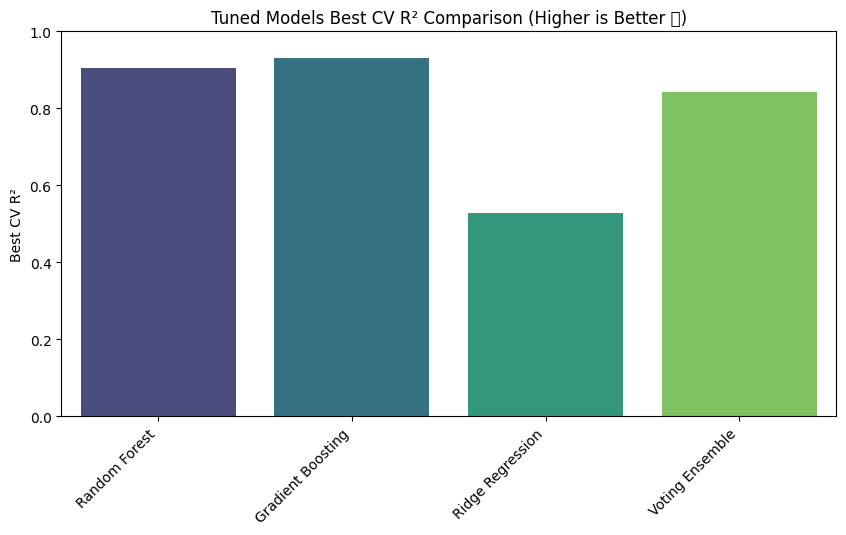

In [42]:
# ===========================
# 2️⃣ Plot Best CV R² (Higher is better)
# ===========================
plt.figure(figsize=(10,5))
sns.barplot(data=tuned_metrics_df, x='Model', y='Best CV R²', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Tuned Models Best CV R² Comparison (Higher is Better ✅)')
plt.ylabel('Best CV R²')
plt.xlabel('')
plt.ylim(0,1)
plt.show()

In [43]:
# ===========================
# 1️⃣ Evaluate tuned models on validation set
# ===========================
tuned_results = {}
for model_name, tuned_model in tuned_models.items():
    y_val_pred = tuned_model.predict(X_val)
    val_r2 = r2_score(y_val, y_val_pred)
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    improvement = val_r2 - results[model_name]['val_r2']  # vs untuned

    tuned_results[model_name] = {
        'val_r2': val_r2,
        'val_rmse': val_rmse,
        'improvement': improvement
    }

In [44]:
# ===========================
# 2️⃣ Print simple comparison table
# ===========================
print(f"{'Model':<20} {'Untuned R²':<12} {'Tuned R²':<12} {'Improvement':<12}")
print("-" * 60)
for model_name, res in tuned_results.items():
    untuned_r2 = results[model_name]['val_r2']
    tuned_r2 = res['val_r2']
    improvement = res['improvement']
    icon = "📈" if improvement > 0 else "📉" if improvement < 0 else "➡️"
    print(f"{model_name:<20} {untuned_r2:>10.4f} {tuned_r2:>10.4f} {icon} {improvement:>8.4f}")

Model                Untuned R²   Tuned R²     Improvement 
------------------------------------------------------------
Random Forest            0.9172     0.9109 📉  -0.0063
Gradient Boosting        0.8669     0.9418 📈   0.0749
Ridge Regression         0.4410     0.4397 📉  -0.0013
Voting Ensemble          0.8198     0.8200 📈   0.0001


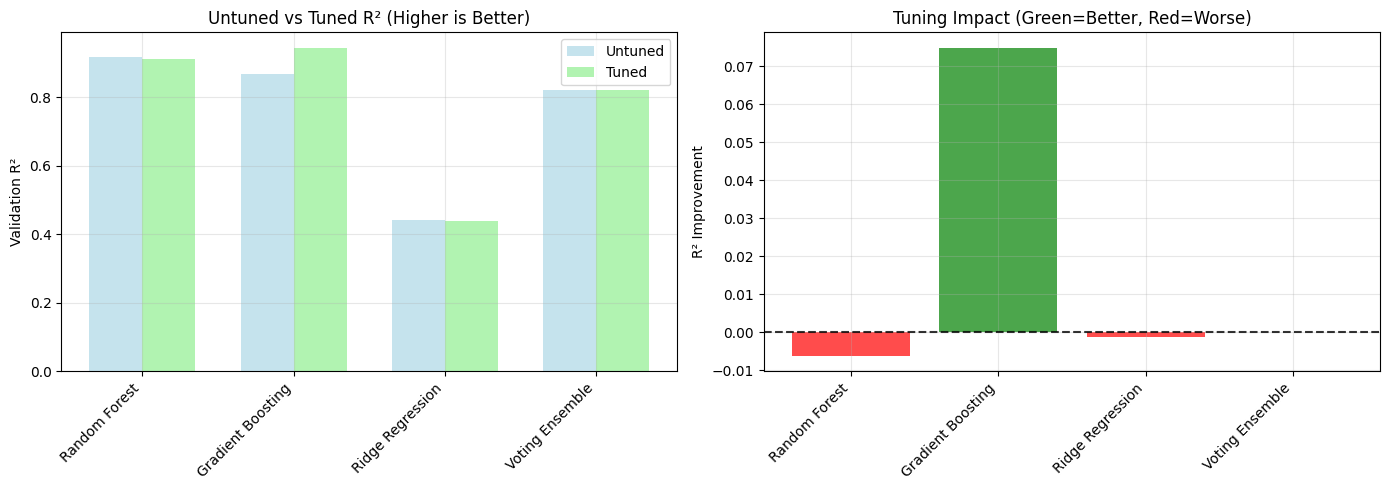

In [45]:
# ===========================
# 3️⃣ Plot Tuned vs Untuned R²
# ===========================
models = list(tuned_results.keys())
untuned_r2 = [results[m]['val_r2'] for m in models]
tuned_r2 = [tuned_results[m]['val_r2'] for m in models]
improvement = [tuned_results[m]['improvement'] for m in models]

x = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# R² comparison
axes[0].bar(x - width/2, untuned_r2, width, label='Untuned', alpha=0.7, color='lightblue')
axes[0].bar(x + width/2, tuned_r2, width, label='Tuned', alpha=0.7, color='lightgreen')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].set_ylabel('Validation R²')
axes[0].set_title('Untuned vs Tuned R² (Higher is Better)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Improvement plot
colors = ['green' if i>0 else 'red' for i in improvement]
axes[1].bar(models, improvement, color=colors, alpha=0.7)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.8)
axes[1].set_ylabel('R² Improvement')
axes[1].set_title('Tuning Impact (Green=Better, Red=Worse)')
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [46]:
# ===========================
# 4️⃣ Best tuned model
# ===========================
best_model_name = max(tuned_results, key=lambda m: tuned_results[m]['val_r2'])
print(f"\n🏆 BEST TUNED MODEL: {best_model_name}")
print(f"📊 Validation R²: {tuned_results[best_model_name]['val_r2']:.4f}")
print(f"📈 Improvement over untuned: +{tuned_results[best_model_name]['improvement']:.4f}")

best_tuned_model = tuned_models[best_model_name] # add this line

# Predict on test set
y_test_pred = best_tuned_model.predict(X_test)

# Compute performance metrics
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"📊 Test R²: {test_r2:.4f}")
print(f"📊 Test RMSE: {test_rmse:.4f}")
print(f"📊 Test MAE: {test_mae:.4f}")


🏆 BEST TUNED MODEL: Gradient Boosting
📊 Validation R²: 0.9418
📈 Improvement over untuned: +0.0749
📊 Test R²: 0.9555
📊 Test RMSE: 1.4931
📊 Test MAE: 1.1003


In [47]:
# ===========================
# 0️⃣ Prepare feature names
# ===========================
# Works for both DataFrame and NumPy array
try:
    feature_names_all = list(X.columns)
except AttributeError:
    feature_names_all = [f"feature_{i}" for i in range(X.shape[1])]

In [48]:
# ===========================
# 1️⃣ Identify best tuned model
# ===========================
best_model_name = max(tuned_results, key=lambda m: tuned_results[m]['val_r2'])
best_tuned_model = tuned_models[best_model_name]

print(f"🏆 BEST TUNED MODEL: {best_model_name}")
print(f"📊 Validation R²: {tuned_results[best_model_name]['val_r2']:.4f}")
print(f"📈 Improvement over untuned: +{tuned_results[best_model_name]['improvement']:.4f}")

🏆 BEST TUNED MODEL: Gradient Boosting
📊 Validation R²: 0.9418
📈 Improvement over untuned: +0.0749


In [49]:
# ===========================
# 2️⃣ Evaluate on Test Set
# ===========================
y_test_pred = best_tuned_model.predict(X_test)
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"\n📊 Test Set Performance:")
print(f"R²: {test_r2:.4f} | RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f}")


📊 Test Set Performance:
R²: 0.9555 | RMSE: 1.4931 | MAE: 1.1003


In [50]:
# ===========================
# 3️⃣ Versioning and saving
# ===========================
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_version = f"v1_{timestamp}"
model_save_dir = os.path.join(config.MODEL_DIR, model_version)
os.makedirs(model_save_dir, exist_ok=True)

# Save model
model_path = os.path.join(model_save_dir, 'best_model.pkl')
joblib.dump(best_tuned_model, model_path)
print(f"✅ Model saved: {model_path}")

# Save preprocessing pipeline
preprocessor_path = os.path.join(model_save_dir, 'preprocessor.pkl')
joblib.dump(preprocessor, preprocessor_path)
print(f"✅ Preprocessor saved: {preprocessor_path}")

✅ Model saved: models/v1_20261008_042011/best_model.pkl
✅ Preprocessor saved: models/v1_20261008_042011/preprocessor.pkl


In [51]:
# ===========================
# 4️⃣ Create model card
# ===========================
model_card = {
    'model_name': best_model_name,
    'model_version': model_version,
    'timestamp': timestamp,
    'dataset': 'NASA Airfoil Self-Noise',
    'target': 'SSPL (dB)',

    'performance': {
        'test_r2': float(test_r2),
        'test_rmse': float(test_rmse),
        'test_mae': float(test_mae),
        'train_r2': float(results[best_model_name]['train_r2']),
        'val_r2': float(tuned_results[best_model_name]['val_r2']),
        'cv_r2_mean': float(results[best_model_name]['cv_r2_mean']),
        'cv_r2_std': float(results[best_model_name]['cv_r2_std']),
    },

    'data_info': {
        'total_samples': int(len(X)),
        'train_samples': int(len(X_train)),
        'val_samples': int(len(X_val)),
        'test_samples': int(len(X_test)),
        'n_features': X_test.shape[1],
        'feature_names': feature_names_all,
    },

    'model_config': {
        'model_class': best_model_name,
        'hyperparameters': dict(best_tuned_model.get_params())
            if hasattr(best_tuned_model, 'get_params') else {},
    },

    'preprocessing': {
        'steps': [
            'AerodynamicFeatureEngineer (log_f, stall flag, alpha^2, alpha*delta, Strouhal, Reynolds, Mach)',
            'OutlierHandler (IQR clipping, fitted on training split only)',
            'RobustScaler (fitted on training split only)',
        ],
        'outlier_factor': 1.5,
    },

    'deployment': {
        'status': 'Ready for Production',
        'recommendations': [
            'Monitor prediction errors in production',
            'Retrain quarterly with new data',
            'Alert if RMSE rises well above the test RMSE (dB)',
        ]
    }
}

card_path = os.path.join(model_save_dir, 'model_card.json')
with open(card_path, 'w') as f:
    json.dump(model_card, f, indent=2, default=str)  # FIX: VotingRegressor params hold estimator objects
print(f"✅ Model card saved: {card_path}")

✅ Model card saved: models/v1_20261008_042011/model_card.json


In [52]:
# ===========================
# 5️⃣ Deployment requirements
# ===========================
requirements = {
    'python': '3.8+',
    'packages': {
        'scikit-learn': '1.0+',
        'numpy': '1.20+',
        'pandas': '1.3+',
        'joblib': '1.0+',
    }
}

req_path = os.path.join(model_save_dir, 'requirements.json')
with open(req_path, 'w') as f:
    json.dump(requirements, f, indent=2)
print(f"✅ Deployment requirements saved: {req_path}")

✅ Deployment requirements saved: models/v1_20261008_042011/requirements.json


In [53]:
# ===========================
# 6️⃣ Summary
# ===========================
print("\n💾 DEPLOYMENT PACKAGE READY")
print(f"Location: {model_save_dir}")


💾 DEPLOYMENT PACKAGE READY
Location: models/v1_20261008_042011


In [54]:
# =====================================================================
# GRADIO UI FOR THE NOTEBOOK  (paste at the END of the notebook)
# Needs these variables from the notebook cells above:
#   best_tuned_model, preprocessor, best_model_name   (and optionally test_rmse, test_r2)
# Each block marked "# ---- CELL n ----" goes in its own notebook cell.
# =====================================================================


# ---- CELL 1 : install (run once, then restart not needed) ----
# !pip install -q gradio


# ---- CELL 2 : build and launch the app ----
import tempfile
from pathlib import Path

import gradio as gr
import numpy as np
import pandas as pd
from matplotlib.figure import Figure
from sklearn.metrics import mean_squared_error, r2_score

# What the app uses (taken straight from the notebook)
MODEL, PRE, MODEL_NAME = best_tuned_model, preprocessor, best_model_name
RMSE = float(test_rmse) if "test_rmse" in globals() else None

FEATURES = ["f", "alpha", "c", "U_infinity", "delta"]
LABELS = {"f": "Frequency", "alpha": "Angle of attack", "c": "Chord length",
          "U_infinity": "Free-stream velocity", "delta": "Displacement thickness"}
RANGES = {"f": (200, 20000), "alpha": (0.0, 22.2), "c": (0.0254, 0.3048),
          "U_infinity": (31.7, 71.3), "delta": (0.0004, 0.0585)}
FREQS = [200, 250, 315, 400, 500, 630, 800, 1000, 1250, 1600, 2000,
         2500, 3150, 4000, 5000, 6300, 8000, 10000, 12500, 16000, 20000]
CHORDS = [0.0254, 0.0508, 0.1016, 0.1524, 0.2286, 0.3048]
VELOCITIES = [31.7, 39.6, 55.5, 71.3]
TESTED = {"f": FREQS, "c": CHORDS, "U_infinity": VELOCITIES}


def predict_df(df):
    """Raw inputs -> same preprocessing as training -> best tuned model."""
    return MODEL.predict(PRE.transform(df[FEATURES].astype(float)))


def input_notes(row):
    notes = []
    for k, (lo, hi) in RANGES.items():
        if not lo <= row[k] <= hi:
            notes.append(f"{LABELS[k]} = {row[k]:g} is outside the training range ({lo:g} to {hi:g}); extrapolation.")
    for k, tested in TESTED.items():
        if RANGES[k][0] <= row[k] <= RANGES[k][1] and not np.isclose(row[k], tested, rtol=1e-6).any():
            notes.append(f"{LABELS[k]} = {row[k]:g} was not a wind-tunnel test value; the model interpolates.")
    return notes


def run_single(f, alpha, c, u, delta):
    try:
        vals = [float(v) for v in (f, alpha, c, u, delta)]
    except (TypeError, ValueError):
        raise gr.Error("Enter a number in all five inputs.")
    row = pd.DataFrame([vals], columns=FEATURES)
    pred = float(predict_df(row)[0])

    text = f"## {pred:.1f} dB\nPredicted scaled sound pressure level (SSPL)"
    if RMSE:
        text += f"\n\nTypical error on the test set: about ±{RMSE:.1f} dB (RMSE)."
    notes = input_notes(row.iloc[0])
    if notes:
        text += "\n\n" + "\n".join(f"- ⚠️ {n}" for n in notes)

    sweep = pd.concat([row] * len(FREQS), ignore_index=True)     # same conditions, all test frequencies
    sweep["f"] = FREQS
    fig = Figure(figsize=(6.4, 3.6), dpi=110, layout="constrained")
    ax = fig.add_subplot(111)
    ax.plot(FREQS, predict_df(sweep), color="#1f6f9f", lw=2, marker="o", ms=3.5)
    ax.scatter([vals[0]], [pred], color="#c2410c", zorder=3, s=45, label="selected frequency")
    ax.set_xscale("log"); ax.grid(alpha=0.3, which="both")
    ax.set_xlabel("Frequency (Hz)"); ax.set_ylabel("Predicted SSPL (dB)")
    ax.set_title("Predicted spectrum at these conditions", fontsize=10)
    ax.legend(frameon=False, fontsize=8)
    return text, fig


def run_batch(file):
    if file is None:
        raise gr.Error("Upload a CSV file first.")
    df = pd.read_csv(file if isinstance(file, str) else file.name)
    missing = [c for c in FEATURES if c not in df.columns]
    if missing:
        raise gr.Error(f"Missing columns: {', '.join(missing)}. Required: {', '.join(FEATURES)}.")
    feats = df[FEATURES].apply(pd.to_numeric, errors="coerce")
    if feats.isna().any().any():
        raise gr.Error("Some feature values are empty or not numeric.")
    df["SSPL_pred"] = predict_df(feats).round(3)
    msg = f"Predicted {len(df):,} rows."
    if "SSPL" in df.columns:
        true = pd.to_numeric(df["SSPL"], errors="coerce"); ok = true.notna()
        msg += (f" Against the SSPL column: R² = {r2_score(true[ok], df.loc[ok, 'SSPL_pred']):.4f}, "
                f"RMSE = {np.sqrt(mean_squared_error(true[ok], df.loc[ok, 'SSPL_pred'])):.3f} dB.")
    out = Path(tempfile.mkdtemp()) / "airfoil_predictions.csv"
    df.to_csv(out, index=False)
    return df.head(200), str(out), msg


num = lambda vals: [(f"{v:g}", v) for v in vals]

with gr.Blocks(title="Airfoil self-noise predictor", theme=gr.themes.Soft(primary_hue="sky")) as demo:
    gr.Markdown(f"# Airfoil self-noise predictor\nPredicts SSPL (dB) with the best tuned model: **{MODEL_NAME}**.")
    with gr.Tabs():
        with gr.Tab("Predict"):
            with gr.Row():
                with gr.Column(scale=5):
                    f = gr.Dropdown(num(FREQS), value=800, allow_custom_value=True, label="Frequency f (Hz)")
                    alpha = gr.Slider(0, 22.2, value=0, step=0.1, label="Angle of attack α (degrees)")
                    c = gr.Dropdown(num(CHORDS), value=0.3048, allow_custom_value=True, label="Chord length c (m)")
                    u = gr.Dropdown(num(VELOCITIES), value=71.3, allow_custom_value=True, label="Free-stream velocity U∞ (m/s)")
                    delta = gr.Slider(0.0004, 0.0585, value=0.0027, step=0.0001,
                                      label="Suction-side displacement thickness δ (m)",
                                      info="Measured boundary-layer thickness; it rises steeply with angle of attack.")
                    btn = gr.Button("Predict SSPL", variant="primary")
                with gr.Column(scale=6):
                    result = gr.Markdown()
                    plot = gr.Plot(label="Spectrum")
            inputs = [f, alpha, c, u, delta]
            btn.click(run_single, inputs, [result, plot])
            demo.load(run_single, inputs, [result, plot])

        with gr.Tab("Batch CSV"):
            gr.Markdown("Upload a CSV with columns `f, alpha, c, U_infinity, delta`. "
                        "If it also has an `SSPL` column, accuracy is reported.")
            up = gr.File(label="CSV file", file_types=[".csv"])
            go = gr.Button("Predict all rows", variant="primary")
            status = gr.Markdown()
            table = gr.Dataframe(label="Predictions (first 200 rows)", interactive=False)
            download = gr.File(label="Download full predictions", interactive=False)
            go.click(run_batch, up, [table, download, status])

demo.launch()          # Colab/Jupyter shows it inline. Add share=True for a temporary public link.


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://673064134bf4979d0f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
